In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder

In [2]:
dataset = pd.read_csv(r"C:\Users\ddeore\OneDrive - SyBridge Technologies\Documents\DD\Python\Uber_ride_data_analysis\UberDataset.csv")

print("\nFirst 5 rows of the database are:\n", dataset.head())
print("\nN(rows,columns):\n", dataset.shape)
print("\nDatabase Info:\n")
dataset.info()


First 5 rows of the database are:
          START_DATE          END_DATE  CATEGORY        START             STOP  \
0  01-01-2016 21:11  01-01-2016 21:17  Business  Fort Pierce      Fort Pierce   
1  01-02-2016 01:25  01-02-2016 01:37  Business  Fort Pierce      Fort Pierce   
2  01-02-2016 20:25  01-02-2016 20:38  Business  Fort Pierce      Fort Pierce   
3  01-05-2016 17:31  01-05-2016 17:45  Business  Fort Pierce      Fort Pierce   
4  01-06-2016 14:42  01-06-2016 15:49  Business  Fort Pierce  West Palm Beach   

   MILES          PURPOSE  
0    5.1   Meal/Entertain  
1    5.0              NaN  
2    4.8  Errand/Supplies  
3    4.7          Meeting  
4   63.7   Customer Visit  

N(rows,columns):
 (1156, 7)

Database Info:

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   str    
 1   END_DATE    1155 non-null   str    
 2  

In [3]:
print("\nBefore cleaning CATEGORY counts:\n", dataset['CATEGORY'].value_counts(dropna=False))
print("\nBefore cleaning PURPOSE counts:\n", dataset['PURPOSE'].value_counts(dropna=False))


Before cleaning CATEGORY counts:
 CATEGORY
Business    1078
Personal      77
NaN            1
Name: count, dtype: int64

Before cleaning PURPOSE counts:
 PURPOSE
NaN                503
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64


In [4]:
# Data Preprocessing
dataset['PURPOSE'] = dataset['PURPOSE'].fillna("NOT")
dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], errors='coerce')

dataset['date'] = dataset['START_DATE'].dt.date
dataset['time'] = dataset['START_DATE'].dt.hour

dataset['day-night'] = pd.cut(
    x=dataset['time'],
    bins=[-1, 10, 15, 19, 24],
    labels=['Morning', 'Afternoon', 'Evening', 'Night']
)

# Drop rows only where important datetime fields failed
dataset.dropna(subset=['START_DATE', 'END_DATE'], inplace=True)

dataset.drop_duplicates(inplace=True)

print("\nAfter cleaning CATEGORY counts:\n", dataset['CATEGORY'].value_counts(dropna=False))
print("\nAfter cleaning PURPOSE counts:\n", dataset['PURPOSE'].value_counts(dropna=False))


After cleaning CATEGORY counts:
 CATEGORY
Business    407
Personal     13
Name: count, dtype: int64

After cleaning PURPOSE counts:
 PURPOSE
NOT                159
Meeting             81
Meal/Entertain      64
Errand/Supplies     47
Customer Visit      46
Temporary Site      14
Between Offices      9
Name: count, dtype: int64


In [5]:
# Object columns
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}
for col in object_cols:
    unique_values[col] = dataset[col].nunique()

print("\nObject columns are:\n", object_cols)
print("\nUnique values in object columns:\n", unique_values)


Object columns are:
 ['date']

Unique values in object columns:
 {'date': 114}


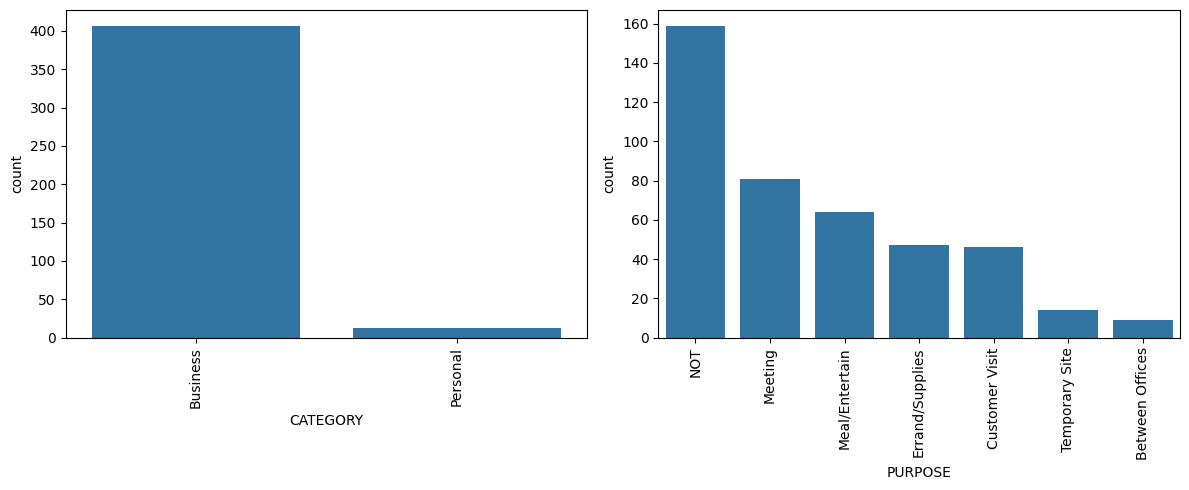

In [6]:
# Data Visualization
#1) 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=dataset['CATEGORY'])
plt.xticks(rotation=90)
plt.subplot(1, 2, 2)
sns.countplot(x=dataset['PURPOSE'], order=dataset['PURPOSE'].value_counts().index)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

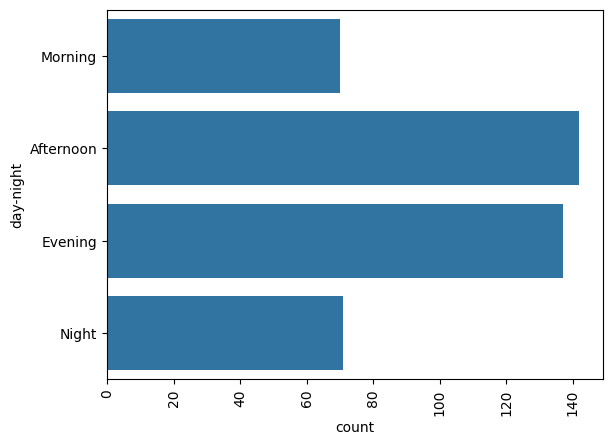

In [7]:
#2)
sns.countplot(dataset['day-night'])
plt.xticks(rotation=90)
plt.show()

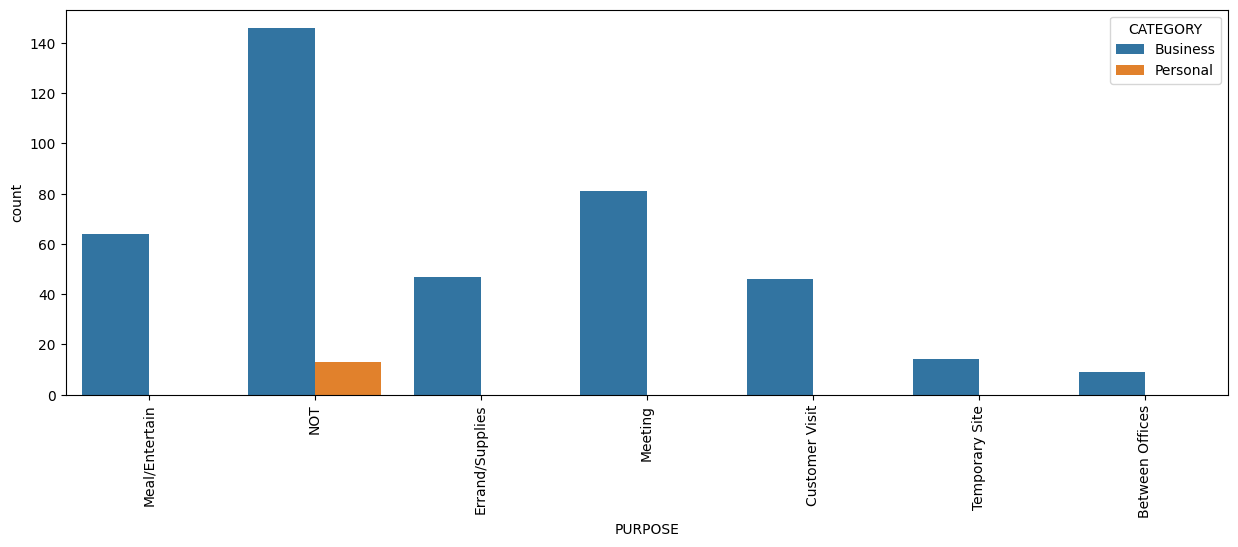

In [8]:
#3)
plt.figure(figsize=(15, 5))
sns.countplot(data=dataset, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

In [9]:
#OneHotEncoder to categories Category and Purpose
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(dataset[object_cols]))
OH_cols.index = dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = dataset.drop(object_cols, axis=1)
dataset = pd.concat([df_final, OH_cols], axis=1)

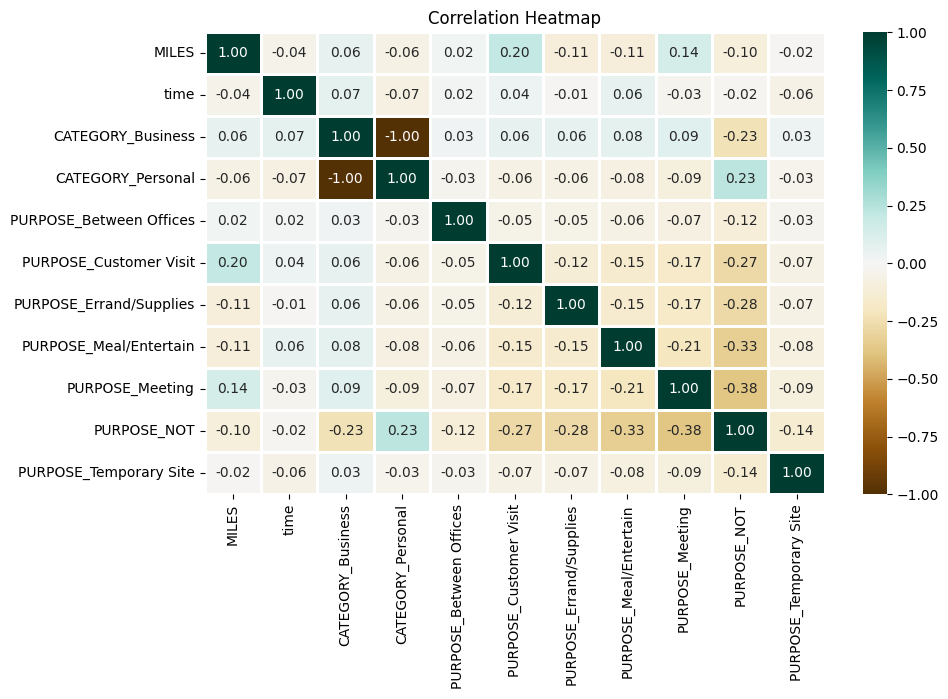

In [10]:
#correlation -> Heatmap
# correlation -> Heatmap

numeric_dataset = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_dataset.corr(),
    cmap='BrBG',
    fmt='.2f',
    linewidths=2,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

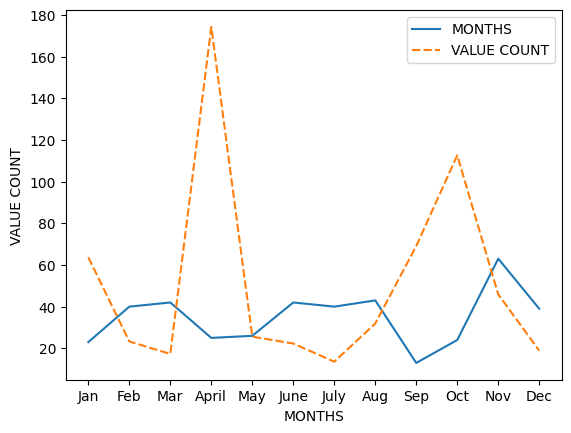

In [11]:
#month by month data analysis
dataset['MONTH'] = pd.DatetimeIndex(dataset['START_DATE']).month
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',
               5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',
               9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
dataset["MONTH"] = dataset.MONTH.map(month_label)

mon = dataset.MONTH.value_counts(sort=False)
df = pd.DataFrame({"MONTHS": mon.values,
                   "VALUE COUNT": dataset.groupby('MONTH',
                                                  sort=False)['MILES'].max()})

p = sns.lineplot(data=df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")
plt.show()

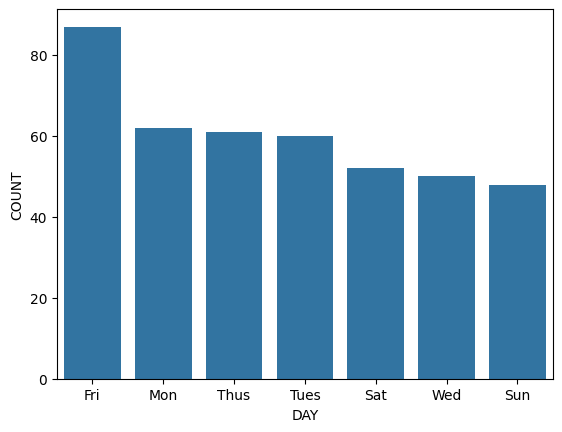

In [12]:
#Visualization for days data
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}
dataset['DAY'] = dataset['DAY'].map(day_label)
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')
plt.show()

C:\Users\ddeore\AppData\Local\Temp\ipykernel_68808\1339872261.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[dataset['MILES']<40]['MILES'])


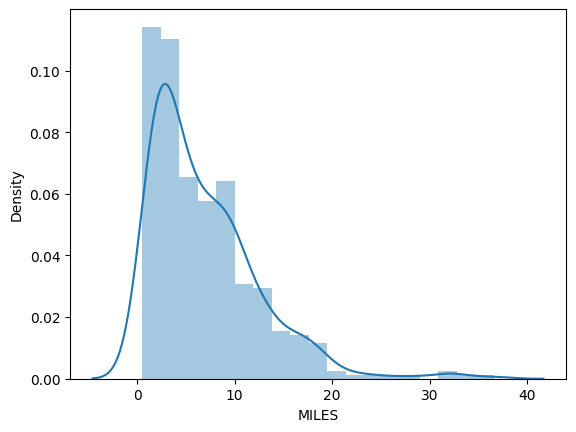

In [13]:
#visualize miles column
sns.distplot(dataset[dataset['MILES']<40]['MILES'])
plt.show()